In [1]:
pip install pmdarima

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [2]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential
from keras.layers import LSTM, Dense
from sklearn.metrics import r2_score

In [3]:
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()
data = pd.read_csv(io.StringIO(uploaded['US Wheat Futures Historical Data.csv'].decode('utf-8')), index_col='Date', parse_dates=True)

Saving US Wheat Futures Historical Data.csv to US Wheat Futures Historical Data (4).csv


In [4]:
# Converting "Price", "Open", "High", "Low", "Vol." columns to float datatype
data['Price'] = data['Price'].str.replace(',', '').astype(float)
data['Open'] = data['Open'].str.replace(',', '').astype(float)
data['High'] = data['High'].str.replace(',', '').astype(float)
data['Low'] = data['Low'].str.replace(',', '').astype(float)
data['Vol.'] = data['Vol.'].str.replace('K', '').astype(float) * 1000.

In [5]:
# fill missing values with mean of the column
data = data.fillna(data.mean())

# Check for null values in each column again
null_counts = data.isnull().sum()

# Print the number of null values in each column
print(null_counts)

Price       0
Open        0
High        0
Low         0
Vol.        0
Change %    0
dtype: int64


<ipython-input-5-4e933ffb9d75>:2: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  data = data.fillna(data.mean())


<Axes: xlabel='Date'>

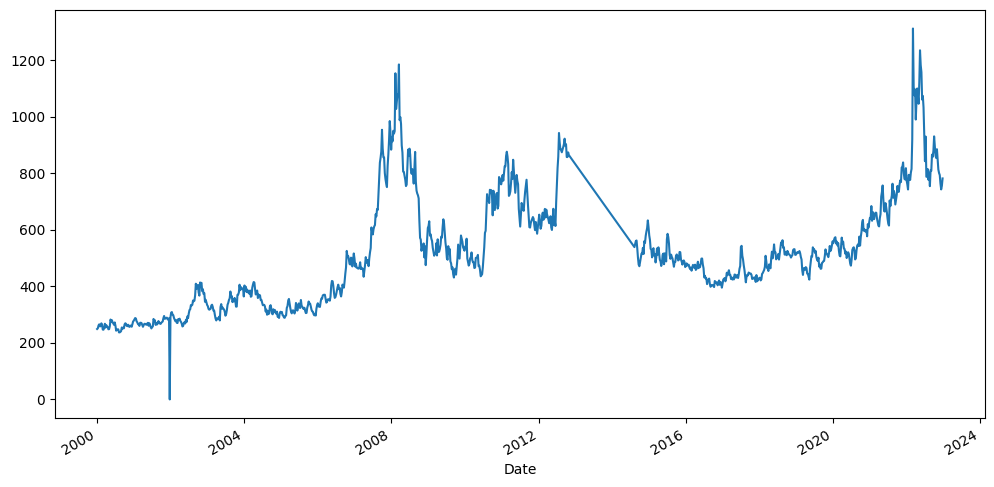

In [6]:
data["Open"].plot(figsize=(12,6))

In [7]:
# Dickey - Fuller Test
from statsmodels.tsa.stattools import adfuller

def ad_test(dataset):
  dftest = adfuller(dataset, autolag ='AIC')
  print("1. ADF: ", dftest[0])
  print("2. p-value: ", dftest[1])
  print("3. No. of lags: ", dftest[2])
  print("4. No. of observations used for ADF Regression and Critical Values Calculations: ", dftest[3])
  print("5. Critical Values: ")
  for key, val in dftest[4].items():
    print("\t", key, ",", val)

In [8]:
ad_test(data['Price'])

1. ADF:  -2.080254015937831
2. p-value:  0.2525283241066988
3. No. of lags:  17
4. No. of observations used for ADF Regression and Critical Values Calculations:  1069
5. Critical Values: 
	 1% , -3.4364819663568262
	 5% , -2.864247479652846
	 10% , -2.568211560046239


In [9]:
from pmdarima import auto_arima
import warnings
warnings.filterwarnings("ignore")

In [10]:
stepwise_fit = auto_arima(data['Price'], trace=True, suppress_warnings=True)
stepwise_fit.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=10631.013, Time=1.81 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=10654.296, Time=0.10 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=10641.063, Time=0.12 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=10641.208, Time=0.23 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=10652.549, Time=0.06 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=10642.244, Time=0.98 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=10638.857, Time=2.17 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=10632.897, Time=3.82 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=10632.899, Time=3.36 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=10643.014, Time=0.85 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=10637.362, Time=1.69 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=10633.784, Time=1.97 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=10619.354, Time=3.82 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=10620.403, Time=2.01 sec
 ARIMA(3,1,4)(0,0,0

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1087
Model:               SARIMAX(3, 1, 3)   Log Likelihood               -5301.778
Date:                Wed, 31 May 2023   AIC                          10617.555
Time:                        06:01:49   BIC                          10652.487
Sample:                             0   HQIC                         10630.779
                               - 1087                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -2.2579      0.119    -18.909      0.000      -2.492      -2.024
ar.L2         -1.7575      0.225     -7.802      0.000      -2.199      -1.316
ar.L3         -0.4766      0.114     -4.167      0.000      -0.701      -0.252
ma.L1          2.1595      0.126     17.111      0.000       1.912       2.407
ma.L2          1.5067      0.242      6.220      0.000       1.032       1.981
ma.L3          0.3165      0.124      2.548      0.011       0.073       0.560
sigma2      1018.1577     17.102     59.534      0.000     984.638    1051.677
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):            111221.52
Prob(Q):                              0.85   Prob(JB):                         0.00
Heteroskedasticity (H):               0.13   Skew:                            -1.32
Prob(H) (two-sided):                  0.00   Kurtosis:                        52.51
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [11]:
# Drop the columns you don't need
data = data.drop(["Change %"], axis=1)

In [12]:
num_rows = data.shape[0]
print("Number of rows:", num_rows)

Number of rows: 1087


In [13]:
import statsmodels.api as sm

In [14]:
# Spllitting the dataset
print(data.shape)
train=data.iloc[:-7]
test=data.iloc[-7:]
print(train.shape, test.shape)

(1087, 5)
(1080, 5) (7, 5)


In [15]:
# Taining the model
model=sm.tsa.arima.ARIMA(train['Price'], order=(1,0,5))
model=model.fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Price   No. Observations:                 1080
Model:                 ARIMA(1, 0, 5)   Log Likelihood               -5283.069
Date:                Wed, 31 May 2023   AIC                          10582.138
Time:                        06:01:51   BIC                          10622.015
Sample:                             0   HQIC                         10597.237
                               - 1080                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        512.0893    102.079      5.017      0.000     312.017     712.161
ar.L1          0.9879      0.005    195.928      0.000       0.978       0.998
ma.L1         -0.1028      0.017     -5.974      0.000      -0.137      -0.069
ma.L2          0.0225      0.029      0.782      0.434      -0.034       0.079
ma.L3          0.0629      0.028      2.238      0.025       0.008       0.118
ma.L4         -0.0802      0.025     -3.256      0.001      -0.128      -0.032
ma.L5          0.0564      0.027      2.119      0.034       0.004       0.109
sigma2      1035.0032     17.349     59.659      0.000    1001.000    1069.006
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):            114104.16
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):               0.13   Skew:                            -1.00
Prob(H) (two-sided):                  0.00   Kurtosis:                        53.32
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [16]:
# Make predictions on the Test dataset
start = len(train)
end = len(train) + len(test)-1
pred = model.predict(start=start, end=end, type='levels')
print(pred)
pred.index = data.index[start:end+1]
print(pred)

1080    248.170770
1081    253.493196
1082    255.613705
1083    258.652333
1084    261.437947
1085    264.460708
1086    267.447015
Name: predicted_mean, dtype: float64
Date
2000-02-13    248.170770
2000-02-06    253.493196
2000-01-30    255.613705
2000-01-23    258.652333
2000-01-16    261.437947
2000-01-09    264.460708
2000-01-02    267.447015
Name: predicted_mean, dtype: float64


<Axes: xlabel='Date'>

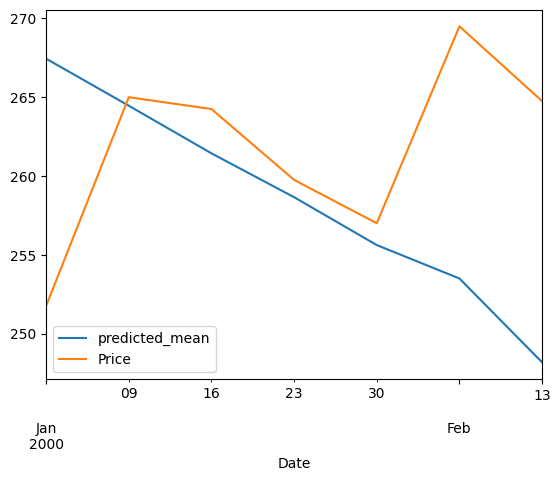

In [17]:
# Plotting the predicted values and the test set
pred.plot(legend=True)
test['Price'].plot(legend=True)

In [18]:
test['Price'].mean()

261.7142857142857

In [19]:
from sklearn.metrics import mean_squared_error
from math import sqrt

rmse=sqrt(mean_squared_error(test['Price'], pred))
print(rmse)

10.615420824146595
